### Importing required data sources & Viewing data for ECB data

In [56]:
# ECB API data
import os
import certifi
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO # Will turn the string to a file like object

# Fix my SSL certificate issue
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# ECB URL - Coming from the European Central Bank (ECB) Data Warehouse / Data Portal API.
url = "https://data-api.ecb.europa.eu/service/data/FM/B.U2.EUR.4F.KR.DFR.LEV?format=csvdata"

# Getting data from ECB
response = requests.get(url)
response.raise_for_status()

# Turn the text 'response' into a DataFrame
df_ecb = pd.read_csv(StringIO(response.text)) # Moves data to pandas

In [57]:
df_ecb.shape

(67, 40)

In [58]:
print(df_ecb.head())

                         KEY FREQ REF_AREA CURRENCY PROVIDER_FM INSTRUMENT_FM  \
0  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
1  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
2  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
3  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
4  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   

  PROVIDER_FM_ID DATA_TYPE_FM TIME_PERIOD  OBS_VALUE  ... UNIT_INDEX_BASE  \
0            DFR          LEV  1999-01-01       2.00  ...             NaN   
1            DFR          LEV  1999-01-04       2.75  ...             NaN   
2            DFR          LEV  1999-01-22       2.00  ...             NaN   
3            DFR          LEV  1999-04-09       1.50  ...             NaN   
4            DFR          LEV  1999-11-05       2.00  ...             NaN   

  COMPILATION  COVERAGE  DECIMALS SOURCE_AGENCY  S

In [59]:
print(df_ecb.columns)

Index(['KEY', 'FREQ', 'REF_AREA', 'CURRENCY', 'PROVIDER_FM', 'INSTRUMENT_FM',
       'PROVIDER_FM_ID', 'DATA_TYPE_FM', 'TIME_PERIOD', 'OBS_VALUE',
       'OBS_STATUS', 'OBS_CONF', 'OBS_PRE_BREAK', 'OBS_COM', 'TIME_FORMAT',
       'BREAKS', 'COLLECTION', 'COMPILING_ORG', 'DISS_ORG', 'DOM_SER_IDS',
       'FM_CONTRACT_TIME', 'FM_COUPON_RATE', 'FM_IDENTIFIER', 'FM_LOT_SIZE',
       'FM_MATURITY', 'FM_OUTS_AMOUNT', 'FM_PUT_CALL', 'FM_STRIKE_PRICE',
       'PUBL_MU', 'PUBL_PUBLIC', 'UNIT_INDEX_BASE', 'COMPILATION', 'COVERAGE',
       'DECIMALS', 'SOURCE_AGENCY', 'SOURCE_PUB', 'TITLE', 'TITLE_COMPL',
       'UNIT', 'UNIT_MULT'],
      dtype='object')


In [60]:
df_ecb.isnull().sum()

KEY                  0
FREQ                 0
REF_AREA             0
CURRENCY             0
PROVIDER_FM          0
INSTRUMENT_FM        0
PROVIDER_FM_ID       0
DATA_TYPE_FM         0
TIME_PERIOD          0
OBS_VALUE            0
OBS_STATUS           0
OBS_CONF             0
OBS_PRE_BREAK       67
OBS_COM             67
TIME_FORMAT          0
BREAKS              67
COLLECTION           0
COMPILING_ORG       67
DISS_ORG            67
DOM_SER_IDS         67
FM_CONTRACT_TIME    67
FM_COUPON_RATE      67
FM_IDENTIFIER       67
FM_LOT_SIZE         67
FM_MATURITY         67
FM_OUTS_AMOUNT      67
FM_PUT_CALL         67
FM_STRIKE_PRICE     67
PUBL_MU             67
PUBL_PUBLIC         67
UNIT_INDEX_BASE     67
COMPILATION         67
COVERAGE            67
DECIMALS             0
SOURCE_AGENCY       67
SOURCE_PUB          67
TITLE                0
TITLE_COMPL          0
UNIT                 0
UNIT_MULT            0
dtype: int64

In [61]:
df_ecb.describe()

,OBS_VALUE,OBS_PRE_BREAK,OBS_COM,BREAKS,COMPILING_ORG,DISS_ORG,DOM_SER_IDS,FM_CONTRACT_TIME,FM_COUPON_RATE,FM_IDENTIFIER,...,FM_STRIKE_PRICE,PUBL_MU,PUBL_PUBLIC,UNIT_INDEX_BASE,COMPILATION,COVERAGE,DECIMALS,SOURCE_AGENCY,SOURCE_PUB,UNIT_MULT
count,67.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,67.0,0.0,0.0,67.0
mean,1.962687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
std,1.279688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
min,-0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
25%,0.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
50%,2.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
75%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
max,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0


In [62]:
df_ecb['OBS_VALUE']

0     2.00
1     2.75
2     2.00
3     1.50
4     2.00
      ... 
62    3.00
63    2.75
64    2.50
65    2.25
66    2.00
Name: OBS_VALUE, Length: 67, dtype: float64

In [63]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   KEY               67 non-null     object 
 1   FREQ              67 non-null     object 
 2   REF_AREA          67 non-null     object 
 3   CURRENCY          67 non-null     object 
 4   PROVIDER_FM       67 non-null     object 
 5   INSTRUMENT_FM     67 non-null     object 
 6   PROVIDER_FM_ID    67 non-null     object 
 7   DATA_TYPE_FM      67 non-null     object 
 8   TIME_PERIOD       67 non-null     object 
 9   OBS_VALUE         67 non-null     float64
 10  OBS_STATUS        67 non-null     object 
 11  OBS_CONF          67 non-null     object 
 12  OBS_PRE_BREAK     0 non-null      float64
 13  OBS_COM           0 non-null      float64
 14  TIME_FORMAT       67 non-null     object 
 15  BREAKS            0 non-null      float64
 16  COLLECTION        67 non-null     object 
 17 

In [64]:
df_ecb.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
62    False
63    False
64    False
65    False
66    False
Length: 67, dtype: bool

In [65]:
df_ecb['OBS_VALUE'].duplicated().any() # This kind of data should have duplicates becuase this is for all of europe.

np.True_

In [66]:
df_ecb['OBS_VALUE'].dtypes

dtype('float64')

In [67]:
df_ecb['TIME_PERIOD'].dtypes

dtype('O')

In [68]:
df_ecb['TIME_PERIOD']

0     1999-01-01
1     1999-01-04
2     1999-01-22
3     1999-04-09
4     1999-11-05
         ...    
62    2024-12-18
63    2025-02-05
64    2025-03-12
65    2025-04-23
66    2025-06-11
Name: TIME_PERIOD, Length: 67, dtype: object

In [69]:
df_ecb['TIME_PERIOD'].min()

'1999-01-01'

----

## Data Wrangling

In [70]:
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD'])

df_ecb = df_ecb[(df_ecb['TIME_PERIOD'] >= '2015-01-01') & (df_ecb['TIME_PERIOD'] <= '2023-12-31')]

In [71]:
# Chaning date format
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD']).dt.strftime('%Y-%m')
df_ecb['TIME_PERIOD'].values

array(['2015-12', '2016-03', '2019-09', '2022-07', '2022-09', '2022-11',
       '2022-12', '2023-02', '2023-03', '2023-05', '2023-06', '2023-08',
       '2023-09'], dtype=object)

In [72]:
# Removing everything expect the data and 'OBS_VALUE'
df_ecb = df_ecb[[ "TIME_PERIOD", "OBS_VALUE"]]

df_ecb = df_ecb.rename(columns={"TIME_PERIOD": "date","OBS_VALUE": "interest"})

In [73]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 46 to 58
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      13 non-null     object 
 1   interest  13 non-null     float64
dtypes: float64(1), object(1)
memory usage: 312.0+ bytes


In [74]:
df_ecb.isnull().sum()

date        0
interest    0
dtype: int64

In [75]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


In [76]:
df_ecb.to_csv("interest_clean.csv", index=False)

In [77]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


----

####  Visualization for ECB & what it shows 

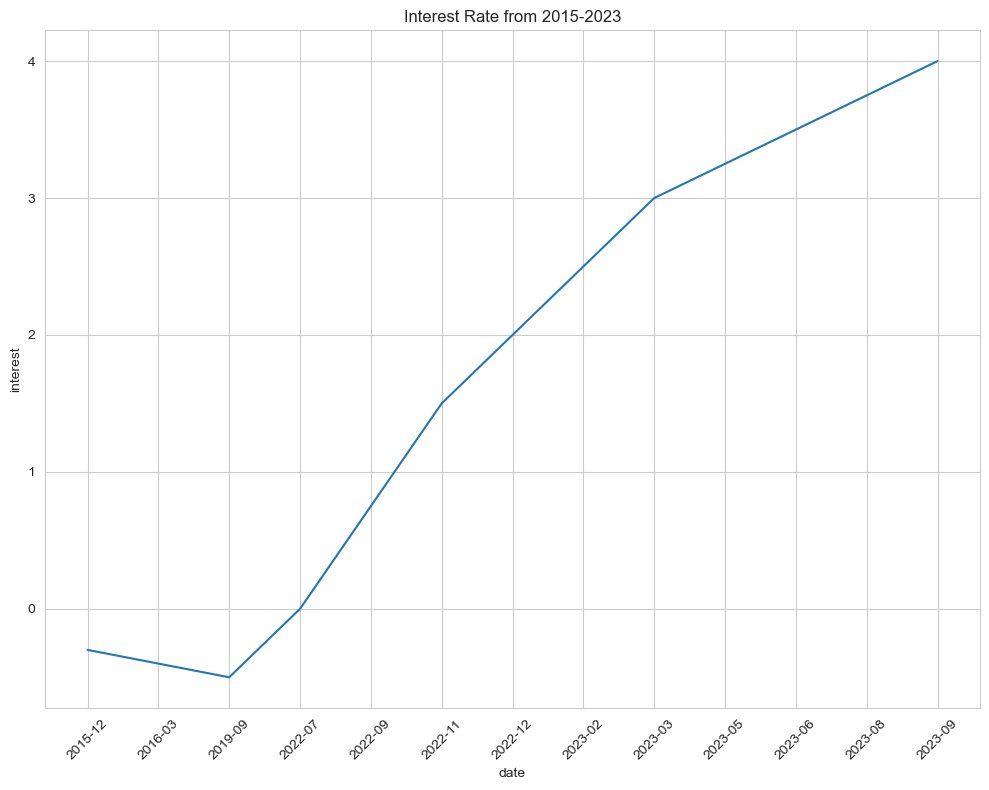

In [78]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,8))
sns.lineplot(data=df_ecb, x='date', y='interest')

plt.xticks(rotation=45)
plt.title('Interest Rate from 2015-2023')
plt.tight_layout()
plt.show()

##### What this graph shows - 
#### Interest rates rise sharply (2022–2023) -- this is a reaction to inflation


----


## Energy rates data

#### Viewing the data

In [79]:
energy_url = 'https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/teicp250/1.0?compress=false&format=csvdata&formatVersion=1.0&lang=en&labels=label_only'

response = requests.get(energy_url)
response.raise_for_status()

df_energy = pd.read_csv(energy_url)

df_energy.head(25)

,DATAFLOW,LAST UPDATE,freq,coicop18,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-04,100.23,NaN,NaN
1,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-05,100.50,NaN,NaN
2,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-06,99.98,NaN,NaN
3,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-07,99.55,NaN,NaN
4,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-08,99.68,NaN,NaN
5,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-09,100.36,NaN,NaN
6,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-10,99.91,NaN,NaN
7,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-11,99.73,NaN,NaN
8,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Albania,2025-12,99.83,NaN,NaN
9,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,"Index, 2025=100",Austria,2025-04,99.80,NaN,NaN


In [80]:
df_energy.tail()

,DATAFLOW,LAST UPDATE,freq,coicop18,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
1381,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,Percentage change m/m-12,Kosovo*,2025-10,4.3,NaN,NaN
1382,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,Percentage change m/m-12,Kosovo*,2025-11,4.7,NaN,NaN
1383,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,Percentage change m/m-12,Kosovo*,2025-12,5.4,NaN,NaN
1384,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,Percentage change m/m-12,Kosovo*,2026-01,3.2,NaN,NaN
1385,ESTAT:TEICP250(1.0),31/03/26 11:00:00,Monthly,Energy,Percentage change m/m-12,Kosovo*,2026-02,2.3,NaN,NaN


In [81]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATAFLOW     1386 non-null   object 
 1   LAST UPDATE  1386 non-null   object 
 2   freq         1386 non-null   object 
 3   coicop18     1386 non-null   object 
 4   unit         1386 non-null   object 
 5   geo          1386 non-null   object 
 6   TIME_PERIOD  1386 non-null   object 
 7   OBS_VALUE    1386 non-null   float64
 8   OBS_FLAG     66 non-null     object 
 9   CONF_STATUS  0 non-null      float64
dtypes: float64(2), object(8)
memory usage: 108.4+ KB


In [82]:
df_energy.describe()

,OBS_VALUE,CONF_STATUS
count,1386.000000,0.0
mean,33.286450,NaN
std,47.277401,NaN
min,-16.100000,NaN
25%,-0.800000,NaN
50%,1.200000,NaN
75%,98.530000,NaN
max,118.900000,NaN


In [83]:
df_energy.isnull().sum()

DATAFLOW          0
LAST UPDATE       0
freq              0
coicop18          0
unit              0
geo               0
TIME_PERIOD       0
OBS_VALUE         0
OBS_FLAG       1320
CONF_STATUS    1386
dtype: int64

-----
